In [1]:
import transformers
import torch

In [2]:
import pandas as pd

In [3]:
train_banking_data = pd.read_csv('datasets/banking77_train.csv')
train_banking_data.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [30]:
top_category_counts = train_banking_data['category'].value_counts().head(15).sort_values(ascending=False)
top_category_counts

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
balance_not_updated_after_bank_transfer             171
transfer_not_received_by_recipient                  171
request_refund                                      169
card_payment_not_recognised                         168
card_payment_wrong_exchange_rate                    167
extra_charge_on_statement                           166
wrong_exchange_rate_for_cash_withdrawal             163
Name: count, dtype: int64

In [17]:
top_categories = train_banking_data['category'].value_counts(normalize=True).head(15).sort_values(ascending=False).index
top_categories

Index(['card_payment_fee_charged', 'direct_debit_payment_not_recognised',
       'balance_not_updated_after_cheque_or_cash_deposit',
       'wrong_amount_of_cash_received', 'cash_withdrawal_charge',
       'transaction_charged_twice', 'declined_cash_withdrawal',
       'transfer_fee_charged', 'balance_not_updated_after_bank_transfer',
       'transfer_not_received_by_recipient', 'request_refund',
       'card_payment_not_recognised', 'card_payment_wrong_exchange_rate',
       'extra_charge_on_statement', 'wrong_exchange_rate_for_cash_withdrawal'],
      dtype='object', name='category')

In [24]:
other_cats_left = len(train_banking_data[~train_banking_data['category'].isin(top_categories)]['category'].value_counts().index)
other_cats_left

62

In [31]:
plt_data = pd.concat([top_category_counts, pd.Series({'other': other_cats_left})])
plt_data.tail()

card_payment_not_recognised                168
card_payment_wrong_exchange_rate           167
extra_charge_on_statement                  166
wrong_exchange_rate_for_cash_withdrawal    163
other                                       62
dtype: int64

In [5]:
import seaborn as sns 
import matplotlib.pyplot as plt

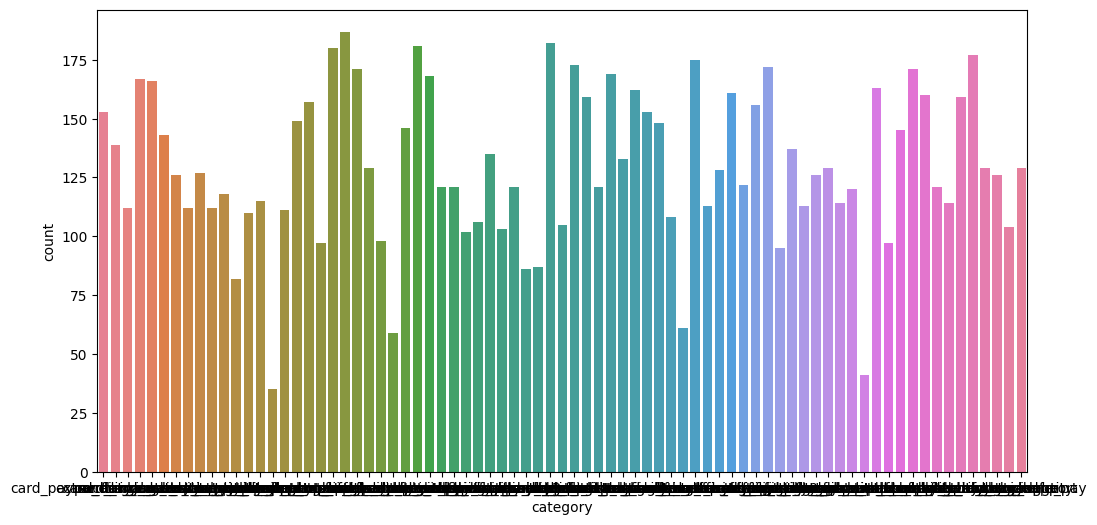

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(x='category', data=train_banking_data, hue='category')
plt.show()

C:\Users\ksk76\AppData\Local\Temp\ipykernel_33836\465265076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plt_data.values, y=plt_data.index, palette="viridis")


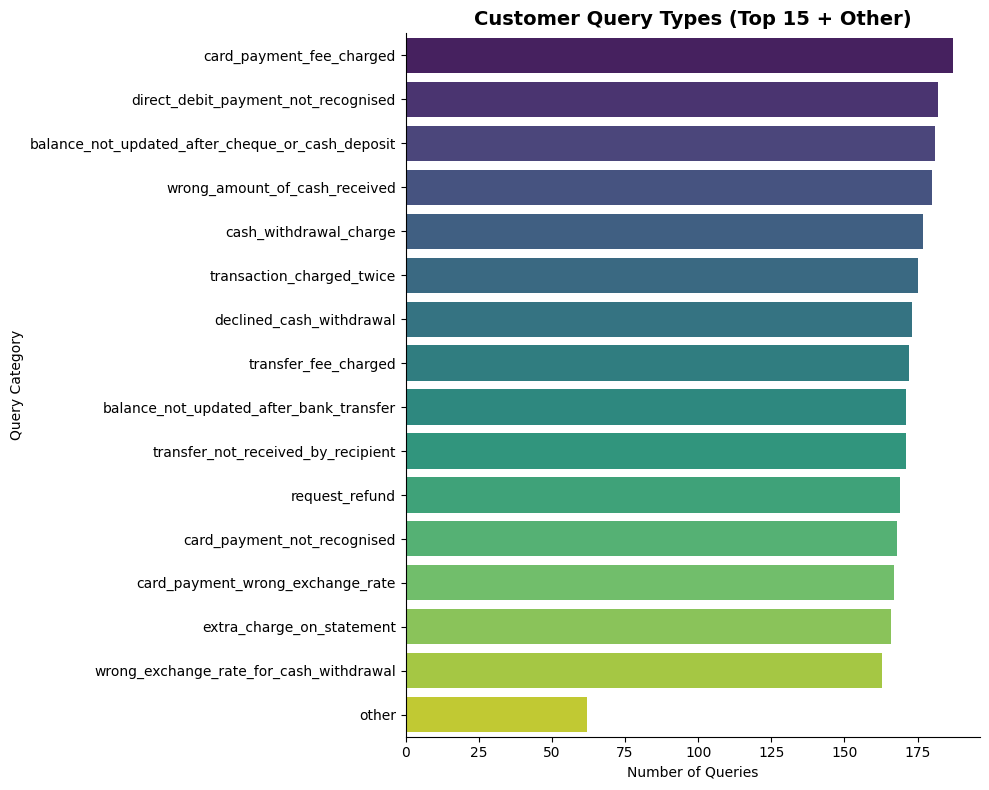

In [32]:
plt.figure(figsize=(10, 8))
sns.barplot(x=plt_data.values, y=plt_data.index, palette="viridis")
plt.title("Customer Query Types (Top 15 + Other)", fontsize=14, weight='bold')
plt.xlabel("Number of Queries")
plt.ylabel("Query Category")
sns.despine()
plt.tight_layout()
plt.show()